<a href="https://colab.research.google.com/github/Basurero2/Estadistica-con-Python-Probabilidad-y-muestreo/blob/juan-carlos/Curso_de_Estad%C3%ADstica_con_Python_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***
# <font color=green size=10>CURSO DE ESTADÍSTICA - PARTE 2</font>
***

# <font color=green>1 CONOCIENDO LOS DATOS</font>
***

## <font color=green>1.1 Dataset del proyecto</font>
***

### Encuesta Nacional por Muestreo de Hogares - 2015

La **Encuesta Nacional por Muestreo de Hogares - ENMH** en Brasil anualmente investiga, de manera permanente, características generales de la población, educación, trabajo, ingresos, vivienda y otras, con frecuencia variables, de acuerdo a las necesidades de información del país, tales como las características de migración, fecundidad, nupcialidad, salud, seguridad alimentaria, entre otros temas. La recopilación de estas estadísticas constituye, durante los 49 años de realización de la investigación, un importante instrumento para la formulación, validación y evaluación de políticas orientadas al desarrollo socioeconómico y la mejora de las condiciones de vida en Brasil.

### Fuente de los Datos

Instituto Brasileño de Geografía y Estadística (IBGE) Encuesta Nacional por Muestreo de Hogares(PNAD) en el 2015

### Variables utilizadas

> ### Ingresos
> ***

Ingresos mensuales del trabajo principal para personas de 10 años o más.

> ### Edad
> ***

Edad del residente en años en la fecha de referencia .

> ### Altura (elaboración propia)
> ***

Altura del habitante en metros.

> ### UF
> ***

Unidad Federal

|Código|Descripción|
|---|---|
|11|Rondônia|
|12|Acre|
|13|Amazonas|
|14|Roraima|
|15|Pará|
|16|Amapá|
|17|Tocantins|
|21|Maranhão|
|22|Piauí|
|23|Ceará|
|24|Rio Grande do Norte|
|25|Paraíba|
|26|Pernambuco|
|27|Alagoas|
|28|Sergipe|
|29|Bahia|
|31|Minas Gerais|
|32|Espírito Santo|
|33|Rio de Janeiro|
|35|São Paulo|
|41|Paraná|
|42|Santa Catarina|
|43|Rio Grande do Sul|
|50|Mato Grosso do Sul|
|51|Mato Grosso|
|52|Goiás|
|53|Distrito Federal|

> ### Sexo
> ***

|Código|Descripción|
|---|---|
|0|Masculino|
|1|Femenino|

> ### Años de Estudio
> ***

|Código|Descripción|
|---|---|
|1|Sin educación o menos de 1 año|
|2|1 año|
|3|2 años|
|4|3 años|
|5|4 años|
|6|5 años|
|7|6 años|
|8|7 años|
|9|8 años|
|10|9 años|
|11|10 años|
|12|11 años|
|13|12 años|
|14|13 años|
|15|14 años|
|16|15 años o más|
|17|No determinado|
||No aplica|

> ### Color
> ***

|Código|Descripción|
|---|---|
|0|Indígena|
|2|Blanco|
|4|Negro|
|6|Amarillo|
|8|Pardo|
|9|Sin declarar|

#### <font color='red'>Nota</font>
***
> Se realizaron los siguientes tratamientos sobre los datos originales:
> 1. Se eliminaron los registros en los que **Ingreso** no era válido. (999 999 999 999);
> 2. Se eliminaron los registros en los que **Ingreso** eran missing;
> 3. Solo se consideraron los registros de **Personas de Referencia** de cada hogar (responsable del hogar).

### Importando pandas y leyendo el dataset del proyecto

https://pandas.pydata.org/

In [133]:
import pandas as pd
import chardet

In [134]:

def detectar_encoding(nombre_archivo):
    # Leemos el archivo en modo binario ('rb')
    with open(nombre_archivo, 'rb') as f:
        resultado = chardet.detect(f.read(10000))
        #lea los primero 10000 caracteres, para predecir el encoding
        # resultado : {'encoding': 'ISO-8859-1', 'confidence': 0.73, 'language': ''}
        #  encoding : tipo de codificacion que se uso en el archivo
        #  confidence : porcentaje de que sea ese tipo de encoding
        #  language : el lenguaje en que esta escrito los datos (español, etc)

    encoding = resultado['encoding']
    confianza = resultado['confidence']

    print(resultado)                                  #mensaje a la consola
    print(f"Encoding detectado: {encoding}")          #mensaje a la consola, encoding
    print(f"Nivel de confianza: {confianza * 100}%")  #mensaje a la consola, procentaje
    return encoding   #valor de la funcion, "ISO-8859-1"

# Uso del código
mi_encoding = detectar_encoding('datos.csv')

{'encoding': 'ISO-8859-1', 'confidence': 0.73, 'language': ''}
Encoding detectado: ISO-8859-1
Nivel de confianza: 73.0%


In [135]:
datos = pd.read_csv("/content/datos.csv", encoding=mi_encoding)
datos

,Ciudad,Sexo,Edad,Color,Años de Estudio,Ingreso,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631
...,...,...,...,...,...,...,...
76835,53,1,46,2,11,812,1.687030
76836,53,0,30,4,7,1500,1.792934
76837,53,0,32,8,12,1300,1.830587
76838,53,0,57,8,4,1500,1.726344


In [136]:
datos = pd.read_csv("/content/datos.csv", encoding="latin-1")
datos.head()
#encoding : latin-1 es forma coloquial de decir "ISO-8859-1", es lo mismo
# se usa para datasets en español, usan "ñ"

,Ciudad,Sexo,Edad,Color,Años de Estudio,Ingreso,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631


In [137]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76840 entries, 0 to 76839
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ciudad           76840 non-null  int64  
 1   Sexo             76840 non-null  int64  
 2   Edad             76840 non-null  int64  
 3   Color            76840 non-null  int64  
 4   Años de Estudio  76840 non-null  int64  
 5   Ingreso          76840 non-null  int64  
 6   Altura           76840 non-null  float64
dtypes: float64(1), int64(6)
memory usage: 4.1 MB


---
---

# <font color=green>2 DISTRIBUCIONES DE PROBABILIDAD</font>
***

## <font color=red>Problema</font>
***

En una competencia para ocupar un puesto de científico de datos, tenemos un total de **10 preguntas** de opción múltiple con **3 alternativas posibles** en cada pregunta. **Cada pregunta tiene el mismo valor.** Suponga que un candidato decide aventurarse sin haber estudiado nada. Decide hacer la prueba con los ojos vendados y adivinar todas las respuestas. Suponiendo que la prueba **vale 10 puntos y la puntuación de corte es 5**, obtenga la probabilidad de que este candidato **acierte 5 preguntas** y también la probabilidad de que el candidato **pase a la siguiente etapa del proceso de selección**.

## <font color=green>2.1 Distribución Binomial</font>
***

Un evento **binomial** se caracteriza por la posibilidad de que solo ocurran dos categorías. Estas categorías juntas representan todo el espacio muestral, siendo también mutuamente excluyentes, es decir, la ocurrencia de una implica la no ocurrencia de la otra.

En el análisis estadístico, el uso más común de la distribución binomial es para resolver problemas que involucran situaciones de **éxito** y **fracaso**.

# $$P(k)=\binom{n}{k} p^k q^{n-k}$$

Donde:

$p$ = probabilidad de éxito

$q = (1 - p)$ = probabilidad de fracaso

$n$ = número de eventos estudiados

$k$ = número de eventos deseados que tienen éxito

### Experimento Binomial

1. Realización de $n$ pruebas idénticas. (misma condiciones)

2. Las pruebas son **independientes** (las pruebas anteriores no afectan en nada a la siguientes).

3. Solo son posibles dos resultados, por ejemplo: **Verdadero o falso**; Cara o cruz; Éxito o fracaso.

4. La probabilidad de éxito está representada por $p$ y la probabilidad de fracaso por $1-p = q$. Estas probabilidades no cambian de una prueba para otra (siempre da la misma probabilidad en siguientes prueba).

### Media de la distribución binomial

El valor esperado o la media de la distribución binomial es igual al número de experimentos realizados multiplicado por la probabilidad de que ocurra el evento.

# $$\mu = n \times p$$

### Desviación estándar de la distribución binomial

La desviación estándar es la raíz quadrada del producto entre el número de experimentos, la probabilidad de éxito y la probabilidad de fracaso.

# $$\sigma = \sqrt{n \times p \times q}$$

### Importando bibliotecas
https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.comb.html

In [138]:
from scipy.special import comb

### Combinaciones

El número de combinaciones de $n$ objetos, tomando $k$ cada vez, es:

# $$C_{k}^{n} = \binom{n}{k} = \frac{n!}{k!(n - k)!}$$

Donde

## $$n! = n\times(n-1)\times(n-2)\times...\times(2)\times(1)$$
## $$k! = k\times(k-1)\times(k-2)\times...\times(2)\times(1)$$

Por definición

## $$0! = 1$$

## <font color='blue'>Ejemplo: Mega Sena</font>

En una rueda de lotería Mega Sena tenemos un total de **60 números** para elegir, donde la apuesta mínima es de **seis números**. Usted que es curioso(a) decide calcular la probabilidad de ganar la Mega Sena con solo **un juego**. Para eso necesitamos saber cuántas **combinaciones de seis números se pueden formar con los 60 números disponibles**.

explicaicon : los juegos de loteria necesitas tener el **conjunto de los numeros solicitados** para ganar, osea que el orden no importa

### $$C_{6}^{60} = \binom{60}{6} = \frac{60!}{6!(60 - 6)!}$$

In [139]:
combinatoria = comb(60, 6)   #combinatoria de 60 en 6
combinatoria
#Cálculo del espacio muestral: total de subconjuntos de 6 elementos posibles en un conjunto de 60.
# elegir 6 numeros de un conjunto de 60 numeros y obtener los combinaciones posibles

np.float64(50063860.0)

In [140]:
probabilidad = 1/combinatoria   # probabilidad de ganar, solo hay un numero ganador (evento exitoso)
probabilidad                    # total de posibles casos (combinatoria)

np.float64(1.997448858318156e-08)

In [141]:
print(f"la probabilida es {probabilidad:.15f}")

la probabilida es 0.000000019974489


## <font color='blue'>Ejemplo: Concurso para científico de datos</font>

En una competencia para ocupar un puesto de científico de datos, tenemos un total de **10 preguntas** de opción múltiple con **3 alternativas posibles** en cada pregunta. **Cada pregunta tiene el mismo valor.** Suponga que un candidato decide aventurarse sin haber estudiado nada. Decide tomar la prueba con los ojos vendados y adivinar todas las respuestas. Suponiendo que la prueba **vale 10 puntos y la puntuación de corte es 5**, obtenga la probabilidad de que este candidato **acierte 5 preguntas** y también la probabilidad de que el candidato **pase a la siguiente etapa del proceso de selección**.

### ¿Cuál es la cantidad de pruebas ($n$), preguntas?

In [142]:
n = 10
n

10

### ¿Las pruebas son independientes?

Sí. La opción elegida en una pregunta no influye en la opción elegida en otra pregunta.

### ¿Sólo dos resultados son posibles en cada prueba?

Sí. El candidato tiene dos posibilidades, ACERTAR o FALLAR una pregunta.

### ¿Cuál es la probabilidad de éxito ($p$)?
- 1 prueba = 1 pregunta
- 3 opciones en cada pregunta (eventos posibles)
- 1 opcion es la correcta (eventos posibles para tener exito)
- a nivel de prueba

In [143]:
p = 1/3
p

0.3333333333333333

### ¿Cuál es la probabilidad de fracaso ($q$)?

In [144]:
q = 1 - p
q

0.6666666666666667

### ¿Cuál es el número total de eventos para tener éxito ($k$)?
- es nuestro primer solucion, buscamos la probabilidad de acertar 5 preguntas (minimo para pasar)
- acertar 5 preguntas (eventos para tener exito)
- total 10 preguntas (eventos posuble)
- a nivel de total de pruebas (total de preguntas)

In [145]:
k = 5
k

5

### Solución 1

# $$P(k)=\binom{n}{k} p^k q^{n-k}$$

In [146]:
n, k, p, q
#total pruebas, total eventos para tener exito, #probablidad exito por prueba, #probabilidad fracaso por prueba

(10, 5, 0.3333333333333333, 0.6666666666666667)

In [147]:
probabilidad = comb(n, k)*(p**k)*(q**(n-k))
probabilidad

np.float64(0.13656454808718185)

### Importando bibliotecas
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html

In [148]:
from scipy.stats import binom

### Solución 2

In [149]:
binom.pmf(k, n, p)
#usamos esta funcion para hallar la distribucion binomial (probabilidad de que ocurra)

np.float64(0.13656454808718146)

### Obtenga la probabilidad de que el candidato apruebe

### $$P(acertar \geq 5) = P(5) + P(6) + P(7) + P(8) + P(9) + P(10)$$

In [150]:
binom.pmf(5, n, p) + binom.pmf(6, n, p) + binom.pmf(7, n, p) + binom.pmf(7, n, p) + binom.pmf(8, n, p) + binom.pmf(9, n, p) + binom.pmf(10, n, p)

np.float64(0.22938576436518784)

In [151]:
binom.pmf([5,6,7,8,9,10], n, p) #hallamos la distribucion binomial para n = 5,6,7,8,9,10

array([1.36564548e-01, 5.69018950e-02, 1.62576843e-02, 3.04831581e-03,
       3.38701756e-04, 1.69350878e-05])

In [152]:
binom.pmf([5,6,7,8,9,10], n, p).sum()
#hallamos la probabilidad total, sumando todas las distribuciones binominales para esos casos

np.float64(0.21312808006909476)

In [153]:
binom.cdf(4, n, p)
#halla la suma de distribuciones binomiales para valores de n = 0,1,2,3,4
#halla hasta eventos de 0 a 4 para tener exito


np.float64(0.7868719199309048)

In [154]:
1 - binom.cdf(4, n, p)
#aplicamos propiedad para obtener la probabilidad restante, para n=5,6,7,8,9,10


np.float64(0.21312808006909523)

In [155]:
binom.sf(4, n, p)
#esta funcion aplica suma de distribucion binomal de n = 0,1,2,3,4 y luego le resta a 1, para
# obtener la probabilidad restante

np.float64(0.21312808006909525)

**Ejemplo** :
Una moneda perfectamente equilibrada se lanza al aire **cuatro veces**. Usando la distribución binomial, obtenga la probabilidad de que la **moneda caiga con la cruz** hacia arriba **dos veces**.

In [156]:
n = 4      #numero de pruebas
p = 1/2    #probabilidad de que salga cruz,  eventos para tener exito/total eventos posibles
q = 1- p   #probabilida de fracaso por prueba
k = 2      #cantidad de eventos para que la probabilidad de que salga cruz sea exitosa

In [157]:
comb(4, 2)*(0.5**2)*(0.5**(4-2))

np.float64(0.375)

In [158]:
binom.pmf(k, n, p)

np.float64(0.375)

**Ejemplo**:
Un dado perfectamente equilibrado se lanza hacia arriba diez veces. Usando la distribución binomial, obtenga la probabilidad de que los dados caigan con el número cinco hacia arriba al menos tres veces.

In [159]:
n = 10      #cantidad de pruebas, lanzamientos
p = 1/6     #probabilidad de exito de una pruba,  salga el numero 5
k = [3, 4, 5, 6, 7, 8, 9, 10]    # numero eventos para que probabilidad de que salga 5 sea exitoso
                                 # al menos 3 veces

In [160]:
binom.pmf(k, n, p).sum()*100  #suma de todas las probabilidades, porcentaje de probabilidad total

np.float64(22.477320212874055)

In [161]:
binom.sf(2, n, p)*100    #porcentaje de probabilidad
#usamos la propiedad de hallar lo contrario y luego le restamos a 1 para obtener la probabilidad restante

np.float64(22.477320212874055)

## <font color='blue'>Ejemplo: Yincana</font>

Una ciudad del interior realiza una yincana cada año para recaudar fondos para el hospital de la ciudad. En la última competencia se sabe que la **proporción de mujeres participantes fue del 60%**. **El número total de equipos, con 12 miembros, inscritos en la yincana de este año es 30**. Con la información anterior, responda: ¿Cuántos equipos deberían estar formados por **8 mujeres**?

### Solución

In [162]:
n = 12   #1 equipo tiene 12 miembros en toal, vamos a realizar 12 pruebas, escojer miembro x miembro
p = 0.6  #probabilidad de que sea mujer en cada seleccion de un miemnbro, yaque el 60% son muejeres, analizar
k = 8    #cantidad de eventos para que la probabilidad de que sea mujer sea exitosa

In [163]:
binom.pmf(k, n, p)   #probabilidad de que haya 8 mujeres en un equipo de 12 miembros,

np.float64(0.21284093952)

In [164]:
u = 30 * binom.pmf(k, n, p)
# media de la distribucion binomial o valor esperado
# cantidad de equipos esperados que cumpla ese requisito (8 mujeres) de un total de 30 equipos
u
#total de pruebas (30 equipos) x probabilidad de que ocurra el evento (1 equipo con 8 muejeres)
# podemos redondear al tratarse de vlaores enteros (numero de equipos)

np.float64(6.3852281856)

**Ejemplo** : Suponga que la probabilidad de que una pareja tenga hijos con ojos azules es del 22%. En 50 familias, con 3 hijos cada una, ¿cuántas podemos esperar que tengan dos hijos con ojos azules?

In [165]:
n = 3
p = 0.22
k = 2

In [166]:
binom.pmf(k, n, p)   #probabilidad de que 1 familia tenga 2 hijos con ojos azules
# esa probabilidad es una cantidad (frecuencia de ocurrir) de una muestra,
# por ejemplo es la probabilidad de 1 familia de n familias,
# o el porcentaje (cantidad de familias) de n familias que cumplen el requisito de tener 2 ojos azules

np.float64(0.11325599999999993)

In [167]:
u = 50*binom.pmf(k, n, p)  #valor esperado de cantidad de familias que tenga 2 ojos azules de 50 familias
u

np.float64(5.662799999999996)

---
---

## <font color=red>Problema</font>
***

Un restaurante recibe un promedio de **20 pedidos por hora**. ¿Cuál es la probabilidad de que, en un momento determinado al azar, el restaurante reciba **15 pedidos**?

## <font color=green>2.2 Distribución Poisson</font>
***

Se utiliza para describir el número de ocurrencias en un tiempo o espacio específico. Los eventos se caracterizan por la posibilidad de contar los éxitos, pero no poder contar los fracasos.

Como ejemplos de procesos donde podemos aplicar la distribución de Poisson tenemos la determinación del número de clientes que ingresan a una tienda en un momento determinado, el número de autos que llegan a un Auto-servicio de una cafetería a la hora del almuerzo, la determinación del número de accidentes registrados en un tramo de carretera, etc.

- Naturaleza del evento: Poisson se aplica a procesos donde los eventos ocurren de manera aleatoria e independiente en el tiempo o espacio.- Inexistencia de $n$: A diferencia de otros modelos, aquí no hay un número fijo de ensayos. Solo observamos cuántas veces sucede algo.
- Cálculo de intervalos: Sí puedes sumar probabilidades o usar el complemento ($1 - P$) para hallar rangos (ej. más de 5 autos, menos de 10 autos), siempre basándote en el número de ocurrencias esperadas ($\lambda$).

- **resumen** : calcular el numero de ocurrencias (probsabilidad) en un intervalo, solo cuenta eventos sucedidos (cuenta ocurrencia de que llegaron 5 autos, pero no de cuantos autos no llegaron (eventos que no suceden, no se puede saber), en cambio en 10 lanzamiento de monedas, si salen 3 caras, sabes cuantos no son caras (7 sellos), aqui si no cumple para poisson)

# $$P(k) = \frac{e^{-\mu}(\mu)^k}{k!}$$

Donde:

$e$ = constante cuyo valor aproximado es 2.718281828459045

$\mu$ o $\lambda$ = representa el número promedio de ocurrencias en un intervalo de tiempo o espacio dado

$k$ = número de éxitos en el intervalo deseado

### Experimento Poisson

1. La probabilidad de que ocurra es la misma en todo el intervalo observado.

2. El número de ocurrencias en un intervalo dado es independiente del número de ocurrencias en otros intervalos.

3. La probabilidad de que ocurra es la misma en intervalos de igual longitud.

### Media de la distribución Poisson

# $$\mu$$

### Desviación estándar de la distribución Poisson

# $$\sigma = \sqrt{\mu}$$

### Importando bibliotecas

http://www.numpy.org/

In [168]:
import numpy as np

## <font color='blue'>Ejemplo: Delivery</font>

Un restaurante recibe un promedio de **20 pedidos por hora**. ¿Cuál es la probabilidad de que, en un momento determinado al azar, el restaurante reciba **15 pedidos**?

# $$P(k) = \frac{e^{-\mu}(\mu)^k}{k!}$$


### ¿Cuál es el número promedio de ocurrencias por hora ($\mu$)?

In [169]:
media = 20 #promedio de ocurrencias en un intervalo, es una muestra
media

20

### ¿Qué número de ocurrencias queremos obtener en el período ($k$)?

In [170]:
k = 15   #numero de ocurrencias que queremos obtener en el intervalo
k

15

### Solución 1

In [171]:
import math

In [172]:
probabilidad = (np.e**(-media))*(media**k)/math.factorial(k)  #distribucion de posisson, probabilidad
probabilidad

0.0516488535317584

### Importando bibliotecas

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.poisson.html

In [173]:
from scipy.stats import poisson

### Solución 2

In [174]:
probabilidad = poisson.pmf(k, media)
#distribucion de posisson,
# k: #eventos que queremos hallar en un intervalo, media: promedia eventos en un intervalo
probabilidad     #5.26% probabilidad de obtener 15 pedidos en una hora

np.float64(0.05164885353175814)

In [175]:
print(f"porcentaje de distribicion de poisson : {probabilidad*100:.2f}%")

porcentaje de distribicion de poisson : 5.16%


In [176]:
print(f"distribicion de poisson : {probabilidad:.8f}")

distribicion de poisson : 0.05164885


In [177]:
print(f"desviacion estandar de distribucion de poisson : {math.sqrt(probabilidad):.8f}")

desviacion estandar de distribucion de poisson : 0.22726384


---
---

## <font color=red>Problema</font>
***

En un estudio sobre la altura de los residentes de una ciudad, se encontró que el conjunto de datos sigue una **distribución aproximadamente normal**, con **media 1.70** y **desviación estándar de 0.1**. Con esta información, obtenga el siguiente conjunto de probabilidades:

> **A.** probabilidad de que una persona, seleccionada al azar, sea menor de 1.80 metros.

> **B.** probabilidad de que una persona, seleccionada al azar, tenga entre 1.60 metros y 1.80 metros.

> **C.** probabilidad de que una persona, seleccionada al azar, tenga más de 1.90 metros.


## <font color=green>2.3 Distribución Normal</font>
***

La distribución normal es una de las más utilizadas en estadística. Es una distribución continua, donde la distribución de frecuencias de una variable cuantitativa tiene forma de campana y es simétrica en relación con su media.

<img src='https://caelum-online-public.s3.amazonaws.com/ESP-1764-estadistica-con-python-probabilidad-y-muestreo/img001.png' width='500px'>

### Características importantes

1. Es simétrica alrededor de la media;

2. El área bajo la curva corresponde a la proporción 1 o 100%;

3. Las medidas de tendencia central (media, mediana y moda) tienen el mismo valor;

4. Los extremos de la curva tienden al infinito en ambas direcciones y, teóricamente, nunca tocan el eje $x$;

5. La desviación estándar define la planitud y el ancho de la distribución. Las curvas más anchas y planas tienen valores de desviación estándar más altos;

6. La distribución se define por su media y desviación estándar;

7. La probabilidad siempre será igual al área bajo la curva, delimitada por los límites superior e inferior.

# $$f(x) = \frac{1}{\sqrt{2\pi\sigma}}e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

Donde:

$x$ = variable normal

$\sigma$ = desviación estándar

$\mu$ = media

La probabilidad se obtiene del área bajo la curva, delimitada por los límites superior e inferior especificados. Se puede ver un ejemplo en la figura siguiente.

<img src='https://caelum-online-public.s3.amazonaws.com/ESP-1764-estadistica-con-python-probabilidad-y-muestreo/img002.png' width='500px'>


Para obtener el área anterior, simplemente calcule la integral de la función para los intervalos determinados. Según la siguiente ecuación:

# $$P(L_i<x<L_s) = \int_{L_i}^{L_s}\frac{1}{\sqrt{2\pi\sigma}}e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

Donde:

$x$ = variable normal

$\sigma$ = desviación estándar

$\mu$ = media

$L_i$ = límite inferior

$L_s$ = límite superior

### Tablas estandarizadas

Se crearon tablas estandarizadas para facilitar la obtención de los valores de las áreas bajo la curva normal y eliminar la necesidad de resolver integrales definidas.

Para ver los valores en una tabla estandarizada, simplemente transforme nuestra variable en una variable estandarizada $Z$.

Esta variable $Z$ representa la desviación en las desviaciones estándar de un valor de la variable original en relación con la media.

# $$Z = \frac{x-\mu}{\sigma}$$

Donde:

$x$ = variable normal con media $\mu$ y desviación estándar $\sigma$

$\sigma$ = desviación estándar

$\mu$ = media

### Construyendo la tabla normal estandarizada
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html

In [178]:
import pandas as pd
import numpy as np
from scipy.stats import norm

tabla_normal_estandarizada = pd.DataFrame(
    [],
    index=["{0:0.2f}".format(i / 100) for i in range(0, 400, 10)],
    columns = ["{0:0.2f}".format(i / 100) for i in range(0, 10)])

for index in tabla_normal_estandarizada.index:
    for column in tabla_normal_estandarizada.columns:
        Z = np.round(float(index) + float(column), 2)
        tabla_normal_estandarizada.loc[index, column] = "{0:0.4f}".format(norm.cdf(Z))

tabla_normal_estandarizada.rename_axis('Z', axis = 'columns', inplace = True)

tabla_normal_estandarizada

Z,0.00,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09
0.00,0.5000,0.5040,0.5080,0.5120,0.5160,0.5199,0.5239,0.5279,0.5319,0.5359
0.10,0.5398,0.5438,0.5478,0.5517,0.5557,0.5596,0.5636,0.5675,0.5714,0.5753
0.20,0.5793,0.5832,0.5871,0.5910,0.5948,0.5987,0.6026,0.6064,0.6103,0.6141
0.30,0.6179,0.6217,0.6255,0.6293,0.6331,0.6368,0.6406,0.6443,0.6480,0.6517
0.40,0.6554,0.6591,0.6628,0.6664,0.6700,0.6736,0.6772,0.6808,0.6844,0.6879
0.50,0.6915,0.6950,0.6985,0.7019,0.7054,0.7088,0.7123,0.7157,0.7190,0.7224
0.60,0.7257,0.7291,0.7324,0.7357,0.7389,0.7422,0.7454,0.7486,0.7517,0.7549
0.70,0.7580,0.7611,0.7642,0.7673,0.7704,0.7734,0.7764,0.7794,0.7823,0.7852
0.80,0.7881,0.7910,0.7939,0.7967,0.7995,0.8023,0.8051,0.8078,0.8106,0.8133
0.90,0.8159,0.8186,0.8212,0.8238,0.8264,0.8289,0.8315,0.8340,0.8365,0.8389


<img src='https://caelum-online-public.s3.amazonaws.com/ESP-1764-estadistica-con-python-probabilidad-y-muestreo/img003.png' width='250px'>

La tabla anterior proporciona el área bajo la curva entre $-\infty$ y $Z$ desviaciones estándar por encima de la media. Recordando que dado que estos son valores estandarizados, tenemos $\mu = 0$.

## <font color='blue'>Ejemplo: ¿Cuánto mides?</font>

En un estudio sobre la altura de los residentes de una ciudad, se encontró que el conjunto de datos sigue una **distribución aproximadamente normal**, con **media 1.70** y **desviación estándar de 0.1**. Con esta información, obtenga el siguiente conjunto de probabilidades:

> **A.** probabilidad de que una persona, seleccionada al azar, mida menos que 1.80 metros.

> **B.** probabilidad de que una persona, seleccionada al azar, mida entre 1.60 metros y 1.80 metros.

> **C.** probabilidad de que una persona, seleccionada al azar, mida más de 1.90 metros.

### Problema A - Identificación del área bajo la curva

<img style='float: left' src='https://caelum-online-public.s3.amazonaws.com/ESP-1764-estadistica-con-python-probabilidad-y-muestreo/img004.png' width='350px'>


### Obtener la variable estandarizada $Z$

In [179]:
x = 1.8                #limite superior,  para hallar probabilidad de altura sea menor a 1.8
media = 1.7            #media alturas
desviacion_estandar = 0.1  #desviacion estandar alturas

In [180]:
z = (x - media)/desviacion_estandar
z

1.0000000000000009

### Solución 1 - Utilizando la tabla

In [181]:
probabilidad = 0.8413
probabilidad
#si buscamos en la tabla estandarizada 1.00 (fila) + 0.0(columna) -> 0.8413

0.8413

### Solución 2 - Utilizando Scipy

In [182]:
from scipy.stats import norm


In [183]:
norm.cdf(z)   #usamos la funcion para hallar la distribucion normal (probabilidad) en intervalo
              # - infinito hasta 1.8,  usamos solo variable estandarizada (z)
#podemos colocar aqui cualquier valor estandarizado, solo necesitamos hallar Z
#en cambio la tabla entandarizada nos da solo valores de z positivos

#probabilidad de que una persona, seleccionada al azar, mida menos que 1.80 metros.

np.float64(0.8413447460685431)

**Ejemplo** : La aplicación de una prueba Estadística en una competencia presentó un conjunto de notas normalmente distribuidas. Se encontró que el conjunto de notas tenía una media de 70 y una desviación estándar de 5 puntos.

¿Qué probabilidad hay de que un estudiante, seleccionado al azar, obtenga una puntuación inferior a 85 puntos?

In [184]:
media = 70                          #promedio de las notas
desviacion_estandar = 5             #desviaicon estandar notas
x = 85                              #limite superior, limite inferior es -infinito


In [185]:
z = (x - media)/desviacion_estandar    #hallamos la variable estandarizada
z

3.0

In [186]:
norm.cdf(z)*100      #aplicamos funcion de distribucion normal usando la variabel estandarizada

np.float64(99.86501019683699)

### Problema B - Identificación del área bajo la curva

<img style='float: left' src='https://caelum-online-public.s3.amazonaws.com/ESP-1764-estadistica-con-python-probabilidad-y-muestreo/img005.png' width='350px'>

### Obtener la variable estandarizada $Z$

In [187]:
media = 1.7
desviacion_estandar = 0.1
limite_superior = 1.8
limite_inferior = 1.6

In [188]:
z_superior = (limite_superior - media)/desviacion_estandar
z_superior

1.0000000000000009

In [189]:
z_inferior = (limite_inferior - media)/desviacion_estandar
z_inferior

-0.9999999999999987

### Solución 1 - Utilizando la tabla

In [190]:
#buscamos en tabla estandarizada, 1.00(fila) + 0.0(columna) -> 8413
probabilidad = 0.8413 - (1 - 0.8413)  #usamos simetria vemos que lo sobrante a la derecha es igual
probabilidad                          # a la izquierda

0.6826000000000001

In [191]:
probabilidad = (0.8413 - 0.5)*2  #usamos simetria del area respecto a la media, es el doble del area
probabilidad                     # debajo la curva desde 1.7 hasta 1.8

0.6826000000000001

### Solución 2 - Utilizando Scipy

In [192]:
probabilidad = norm.cdf(z_superior) - (1 - norm.cdf(z_superior))
probabilidad

np.float64(0.6826894921370863)

In [193]:
probabilidad = norm.cdf(z_superior) - norm.cdf(z_inferior)
probabilidad
#probabilidad de que una persona, seleccionada al azar, tenga entre 1.60 metros y 1.80 metros.

np.float64(0.6826894921370857)

**Ejemmplo** : La facturación diaria de un controlador de aplicación sigue una distribución aproximadamente normal, con un media de $ 300,00 y una desviación estándar igual a $ 50,00. Obtenga las probabilidades de que, en un día aleatorio, el conductor gane:

1) Entre $ 250,00 y $ 350,00

2) Entre $ 400,00 y $ 500,00

Solcion 1

In [194]:
z_superior = (350 - 300)/50
z_inferior = (250 - 300)/50

In [195]:
(norm.cdf(z_superior) - norm.cdf(z_inferior))*100
#probabilidad el conductor gane: Entre $ 250,00 y $ 350,00

np.float64(68.26894921370858)

Solucion 2

In [196]:
z_superior = (500 - 300)/50
z_inferior = (400 - 300)/50

In [197]:
(norm.cdf(z_superior) - norm.cdf(z_inferior))*100
#probabilidad el conductor gane: Entre $ 400,00 y $ 500,00

np.float64(2.271846070634609)

### Problema C - Identificación del área bajo la curva

<img style='float: left' src='https://caelum-online-public.s3.amazonaws.com/ESP-1764-estadistica-con-python-probabilidad-y-muestreo/img006.png' width='350px'>

### Obtener la variable estandarizada $Z$

Hallar la area bajo la curva de limite de 1.9 hasta +infinito

In [198]:
media, desviacion_estandar

(1.7, 0.1)

In [199]:
z_inferior = (1.9 - media)/desviacion_estandar
z_inferior

1.9999999999999996

### Solución 1 - Utilizando la tabla

In [200]:
probabilidad =  1 - 0.9767   #aplicamos la propiedad de simetria, obtener lo restante
probabilidad

0.023299999999999987

### Solución 2 - Utilizando Scipy

In [201]:
probabilidad = 1 - norm.cdf(z_inferior)   #aplicamos propiedad simetria o complemento por simetria
probabilidad

np.float64(0.02275013194817921)

In [202]:
probabilidad = norm.cdf(-z_inferior)  #aplicamos propiedad simetria o complemento de simetria
probabilidad                          #cdf : Cumulative Distribution Function
                                      #   area desde -infinito hasta un punto

np.float64(0.022750131948179216)

In [203]:
probabilidad = norm.sf(z_inferior)  #ausamos la "survival function"
probabilidad                        #area desde ese punto hasta +infinito

np.float64(0.022750131948179216)

**Ejemplo** : Una empresa verificó que las lámparas incandescentes XPTO tienen una vida útil normalmente distribuida, con un media igual a 720 días y una desviación estándar igual a 30 días. Calcula la probabilidad de que una lámpara, elegida al azar, dure:

1) Entre 650 y 750 días

2) Más de 800 días

3) Menos de 700 días

Solucion 1

In [204]:
z_inferior =  (650 - 720)/30
z_superior = (750 - 720)/30

In [205]:
(norm.cdf(z_superior) - norm.cdf(z_inferior))*100  #probabilidad de que dure entre 650 y 750 días

np.float64(83.15294174398976)

Solucion 2

In [206]:
z_inferior =  (800 - 720)/30

In [207]:
(norm.cdf(-z_inferior))*100  #probabilidad de que dure más de 800 días

np.float64(0.3830380567589736)

Solucion 3

In [208]:
z_superior = (700 - 720)/30

In [209]:
(norm.cdf(z_superior))*100  #probabilidad de que dure menos de 700 días

np.float64(25.24925375469229)

In [210]:
norm.cdf(1.96)

np.float64(0.9750021048517795)

In [211]:
norm.sf(2.15)

np.float64(0.0157776073910905)

In [212]:
norm.sf(0.78)

np.float64(0.21769543758573312)

In [213]:
norm.sf(0.59)

np.float64(0.27759532475346493)

# <font color=green>3 MUESTREO</font>
***

## <font color=green>3.1 Población y Muestra</font>
***

### Población
Conjunto de todos los elementos de interés de un estudio. Varios elementos pueden componer una población, por ejemplo: personas, edades, alturas, automóviles, etc.

En cuanto al tamaño, las poblaciones pueden ser limitadas (poblaciones finitas) o ilimitadas (poblaciones infinitas).

### Poblaciones finitas

Permiten el recuento de sus elementos. Los ejemplos incluyen el número de empleados en una empresa, el número de estudiantes en una escuela, etc.

### Poblaciones infinitas

No es posible contar sus elementos. Como ejemplos tenemos el número de porciones que se pueden extraer del agua del mar para su análisis, la temperatura medida en cada punto de un territorio, etc.

<font color=red>Cuando se pueden contar los elementos de una población, pero presentando una cantidad muy grande, se supone que la población es infinita.</font>

### Muestra
Subconjunto representativo de la población.

Los atributos numéricos de una población, como su **media, varianza y desviación estándar**, se conocen como **parámetros**. El enfoque principal de la inferencia estadística es precisamente generar estimaciones y probar hipótesis sobre parámetros poblacionales utilizando información de la muestra.

## <font color=green>3.2 ¿Cuándo usar una muestra?</font>
***

### Poblaciones infinitas

El estudio nunca llegaría a su fin. No es posible investigar todos los elementos de la población.

### Pruebas destructivas

Estudios donde los elementos evaluados son totalmente consumidos o destruidos. Ejemplo: pruebas de vida útil, pruebas de seguridad en accidentes de tráfico.

### Resultados rápidos

Investigaciones que necesitan más agilidad en la difusión. Ejemplo: encuestas de opinión, encuestas sobre problemas de salud pública.

### Altos precios

Cuando la población es finita pero muy grande, el costo de un censo puede hacer inviable el proceso.

## <font color=green>3.3 Muestreo Aleatorio Simple</font>
***

Es una de las principales formas de extraer una muestra de una población. El requisito fundamental de este tipo de enfoque es que cada elemento de la población tenga las mismas posibilidades de ser seleccionado para formar parte de la muestra.

In [214]:
datos.head()     #poblacion

,Ciudad,Sexo,Edad,Color,Años de Estudio,Ingreso,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631


In [215]:
datos.shape     #dimensiones de nuestra poblacion

(76840, 7)

In [216]:
datos.mean()

,0
Ciudad,31.912962
Sexo,0.307002
Edad,44.071421
Color,5.032613
Años de Estudio,9.469664
Ingreso,2000.383199
Altura,1.699512


In [217]:
muestra = datos.sample(n=100, random_state=101)  #probamos una muestra de 100 datos aleatorios
#random_state : es como la semlla, para que nos dea los mismo datos aleatorios

In [218]:
datos.Ingreso.mean()     #media de datos Ingreso de la Poblacion

np.float64(2000.3831988547631)

In [219]:
muestra.Ingreso.mean()   #media de datos Ingreso de la Muestra
#vemos que se acerca a la media de la Poblacion, mientras mas cerca es mas representativa
#normalmente mientras mas grande es la muestra el valor se acerca

np.float64(2150.85)

In [220]:
datos.Sexo.value_counts(normalize=True)   #proporcion de datos Sexo (masculino (0), femenino (1))
                                          # Poblacion

,proportion
Sexo,
0,0.692998
1,0.307002


In [221]:
muestra.Sexo.value_counts(normalize=True)   #proporcion de datos Sexo (masculino (0), femenino (1))
                                            # Muestra
                                            # vemos que se acerca a los valores tomados en la poblacion

,proportion
Sexo,
0,0.69
1,0.31


In [222]:
muestra = datos.sample(n=1000, random_state=101)  #probamos con una muestra mas grande

In [223]:
datos.Ingreso.mean()

np.float64(2000.3831988547631)

In [224]:
muestra.Ingreso.mean()

np.float64(1998.783)

In [225]:
datos.Sexo.value_counts(normalize=True)

,proportion
Sexo,
0,0.692998
1,0.307002


In [226]:
muestra.Sexo.value_counts(normalize=True)
#los valores deberian estar mas proximos a la de poblacion, al ser una muestra mas grande

,proportion
Sexo,
0,0.706
1,0.294


## <font color=green>3.4 Muestreo Estratificado</font>
***

Es una mejora del proceso de muestreo aleatorio simple. En este método, se propone dividir la población en subgrupos de elementos con características similares, es decir, grupos más homogéneos. Con estos subgrupos separados, la técnica de muestreo aleatorio simple dentro de cada subgrupo se aplica individualmente.

## <font color=green>3.5 Muestreo por Conglomerados</font>
***

También tiene como objetivo mejorar el criterio de muestreo aleatorio simple. En el muestreo por conglomerados también se crean subgrupos, pero no serán homogéneos como en el muestreo estratificado. En el muestreo por conglomerados los subgrupos serán heterogéneos, donde luego se aplicará un muestreo aleatorio simple o estratificado.

Un ejemplo muy común de la aplicación de este tipo de técnica es la división de la población en grupos territoriales, donde los elementos investigados tendrán características bastante variadas.

# <font color=green>4 ESTIMACIÓN</font>
***

## <font color='red'>Problema </font>

Suponga que los pesos de las bolsas de arroz de una industria alimentaria se distribuyen aproximadamente como una distribución normal **desviación estándar igual a 150 g**. Se seleccionó una **muestra aleatoria de 20 bolsas** de un lote específico, se obtuvo un **peso promedio de 5.050 g**. Construya un **intervalo de confianza para la media de la población** asumiendo un **nivel de significancia del 5%**.

---

Es la forma de hacer suposiciones generalizadas sobre los parámetros de una población a partir de información de una muestra.

- **Los parámetros** son los atributos numéricos de una población, como la media, la desviación estándar, etc.

- **Estimación** es el valor obtenido para un parámetro dado a partir de los datos de una muestra de la población.

## <font color=green>4.1 Teorema central del límite</font>
***

> El **Teorema Central del Límite** establece que, con el aumento del tamaño de la muestra, la distribución de las medias muestrales se aproxima a una distribución normal con media igual a la media de la población y una desviación estándar igual a la desviación estándar de la variable original dividida por la raíz cuadrada del tamaño de la muestra. Este hecho está asegurado para $n$ mayores o iguales a 30.

# $$\sigma_\bar{x} = \frac{\sigma}{\sqrt{n}}$$

La desviación estándar de las medias muestrales se conoce como **error estándar de la media**

### Entendiendo el Teorema Central del Límite

In [227]:
datos.head()

,Ciudad,Sexo,Edad,Color,Años de Estudio,Ingreso,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631


In [228]:
n = 2000                    #tamaño de la muestra
total_de_muestras = 1500    #necesita varias experimentos para obtener un mejor resultado
                            #(N) son como el numero de barras para el histograma de medias
                            #numero de columnas (muestra 1, muestra, 2, etc) de nuestro DataFrame de medias

In [229]:
muestras = pd.DataFrame()
#creamos un DataFrame para llenar todas las muestras (N) con un tamaño de muestra iguaal (n)

In [230]:
for i in range(0,total_de_muestras):
  _ = datos.Edad.sample(n)          #guardamos una muestra con tamaño 1500
  _.index = range(0, n)             #ponemos indice 0 hasta n (tamaño muestra), es como reset_index
  muestras["Muestra_" + str(i)] = _ #guardamos cada muestra en una columna (2000) (N)



/tmp/ipykernel_203/1360121275.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  muestras["Muestra_" + str(i)] = _ #guardamos cada muestra en una columna (2000) (N)
/tmp/ipykernel_203/1360121275.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  muestras["Muestra_" + str(i)] = _ #guardamos cada muestra en una columna (2000) (N)
/tmp/ipykernel_203/1360121275.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining al

In [231]:
muestras   #DataFrame con 1500 experimentos (N) para un tamaño de muestra 1500 (m) de variable Edad

,Muestra_0,Muestra_1,Muestra_2,Muestra_3,Muestra_4,Muestra_5,Muestra_6,Muestra_7,Muestra_8,Muestra_9,...,Muestra_1490,Muestra_1491,Muestra_1492,Muestra_1493,Muestra_1494,Muestra_1495,Muestra_1496,Muestra_1497,Muestra_1498,Muestra_1499
0,48,38,41,34,49,39,55,49,35,52,...,40,41,35,44,47,39,65,55,27,25
1,38,51,44,65,65,57,39,54,27,57,...,62,44,29,33,51,50,25,32,47,56
2,61,46,50,61,47,35,44,33,43,36,...,83,55,53,68,58,39,41,47,49,37
3,41,38,72,50,24,22,50,38,37,27,...,32,20,47,60,52,33,52,41,35,39
4,45,37,42,38,37,34,60,33,52,29,...,39,55,25,46,36,63,46,53,57,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,68,39,57,57,53,46,48,34,54,52,...,49,40,34,40,26,52,25,49,33,61
1996,21,47,54,38,47,30,32,63,61,34,...,40,35,36,38,50,58,30,39,36,52
1997,31,35,47,48,43,75,25,29,36,45,...,58,47,51,31,18,43,48,31,46,25
1998,52,45,65,63,64,38,80,50,60,46,...,53,65,26,74,54,35,33,40,38,38


In [232]:
muestras.mean()   #medias de todas las muestras de variable Edad

,0
Muestra_0,43.9760
Muestra_1,44.3100
Muestra_2,44.0875
Muestra_3,44.2885
Muestra_4,43.9085
...,...
Muestra_1495,43.9910
Muestra_1496,43.9620
Muestra_1497,44.1560
Muestra_1498,44.3415


> El **Teorema Central del Límite** establece que, con el aumento del tamaño de la muestra, la distribución de las medias muestrales se aproxima a una distribución normal con media igual a la media de la población y una desviación estándar igual a la desviación estándar de la variable original dividida por la raíz cuadrada del tamaño de la muestra. Este hecho está asegurado para $n$ mayores o iguales a 30.

<Axes: >

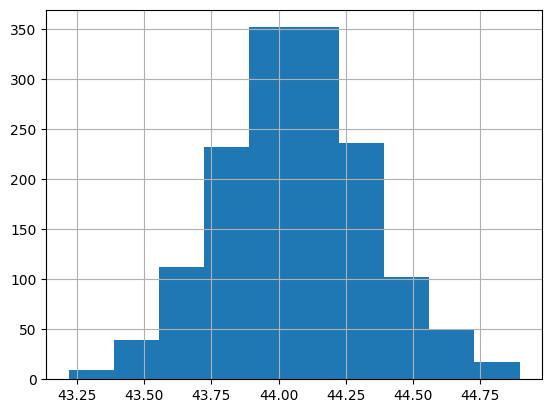

In [233]:
muestras.mean().hist()  #histograma de las medias de todas las muestras
#tendencia a distribucion normal
#"con el aumento del tamaño de la muestra
#  la distribución de las medias muestrales se aproxima a una distribución normal"

> El **Teorema Central del Límite** establece que, con el aumento del tamaño de la muestra, la distribución de las medias muestrales se aproxima a una distribución normal con media igual a la media de la población y una desviación estándar igual a la desviación estándar de la variable original dividida por la raíz cuadrada del tamaño de la muestra. Este hecho está asegurado para $n$ mayores o iguales a 30.

In [234]:
datos.Edad.mean()              #media de nuestro datos originales (Poblacion)

np.float64(44.07142113482561)

In [235]:
muestras.mean().mean()        #media de las medias de nuestras muestras de Edad (muestra)
#segun TCL estas medias tienden a aproximarse al orginal, mientras mas grande tamaño de la muestra (n)
# TCL:"con el aumento del tamaño de la muestra se aproxima a una media igual a la media de la población"

np.float64(44.06388299999999)

> El **Teorema Central del Límite** establece que, con el aumento del tamaño de la muestra, la distribución de las medias muestrales se aproxima a una distribución normal con media igual a la media de la población y una desviación estándar igual a la desviación estándar de la variable original dividida por la raíz cuadrada del tamaño de la muestra. Este hecho está asegurado para $n$ mayores o iguales a 30.

# $$\sigma_\bar{x} = \frac{\sigma}{\sqrt{n}}$$

In [236]:
muestras.mean().std()   #desviaicon estandar de las medias de la muestras de variable Edad

0.2749527398489304

In [237]:
datos.Edad.std()/math.sqrt(n)
#TCL : con el aumento del tamaño de la muestra se aproxima
# una desviación estándar de las medias de las muestras
# igual a la desviación estándar de la variable original (Edad) dividida
# por la raíz cuadrada del tamaño de la muestra (n).
# siendo n >= 30

0.2790743302740527

## <font color=green>4.2 Los niveles de confianza y significación</font>
***

El **nivel de confianza** ($1 - \alpha$) representa la probabilidad de que la estimación sea correcta. Además, el **nivel de significancia** ($\alpha$) expresa la probabilidad de error de la estimación.

El **nivel de confianza** representa el grado de confiabilidad del resultado estimado dentro de un cierto rango. Cuando establecemos un **nivel de confianza del 95%** en una encuesta, por ejemplo, estamos asumiendo que existe una probabilidad del 95% de que los resultados de la encuesta representen bien la realidad, es decir, sean correctos.

El **nivel de confianza** de una estimación se puede obtener del área bajo la curva normal como se muestra en la figura siguiente.

<img src='https://caelum-online-public.s3.amazonaws.com/ESP-1764-estadistica-con-python-probabilidad-y-muestreo/img007.png' width='450px'>


## <font color=green>4.3 Error inferencial</font>
***

El **error inferencial** se define por la **desviación estándar de las medias muestrales** $\sigma_\bar{x}$ y por el **nivel de confianza** determinado para el proceso.

# $$e = z \frac{\sigma}{\sqrt{n}}$$

## <font color=green>4.4 Intervalos de confianza</font>
***

### Intervalo de confianza para la media poblacional

#### Con desviación estándar poblacional conocida

## $$\mu = \bar{x} \pm z\frac{\sigma}{\sqrt{n}}$$

#### Con desviación estándar de población desconocida

## $$\mu = \bar{x} \pm z\frac{s}{\sqrt{n}}$$
- te dan la desviacion estandar de la muestra
- si n >= 30
- sino usamos t (student) es una grafica mas achatada y colas mas gruesas (elevadas) para evitar una mayor incertidumbre

## $$\mu = \bar{x} \pm t\frac{s}{\sqrt{n}}$$



## <font color='blue'>Ejemplo: </font>

Suponga que los pesos de las bolsas de arroz de una industria alimentaria se distribuyen aproximadamente como una población normal con **desviación estándar igual a 150 g**. Se seleccionó una **muestra aleatoria de 20 bolsas** de un lote específico, se obtuvo un **peso promedio de 5.050 g**. Construya un intervalo de confianza para el **promedio de la población** asumiendo un **nivel de significancia del 5%**.

### Media muestral

In [238]:
media_muestras = 5.05
media_muestras

5.05

### Nivel de significancia ($\alpha$)

In [239]:
nivel_significancia = 0.05
nivel_significancia

0.05

### Nivel de confianza ($1 - \alpha$)

In [240]:
nivel_de_confianza = 1 - nivel_significancia    #area bajo la curva entre intervalos  -z hasta +z
nivel_de_confianza                              # curva estandarizada

0.95

### Obteniendo $z$ con la tabla estandarizada

In [241]:
tabla_normal_estandarizada[16:26]   #seleccionamos fila 16 hasta 26

Z,0.00,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09
1.60,0.9452,0.9463,0.9474,0.9484,0.9495,0.9505,0.9515,0.9525,0.9535,0.9545
1.70,0.9554,0.9564,0.9573,0.9582,0.9591,0.9599,0.9608,0.9616,0.9625,0.9633
1.80,0.9641,0.9649,0.9656,0.9664,0.9671,0.9678,0.9686,0.9693,0.9699,0.9706
1.90,0.9713,0.9719,0.9726,0.9732,0.9738,0.9744,0.9750,0.9756,0.9761,0.9767
2.00,0.9772,0.9778,0.9783,0.9788,0.9793,0.9798,0.9803,0.9808,0.9812,0.9817
2.10,0.9821,0.9826,0.9830,0.9834,0.9838,0.9842,0.9846,0.9850,0.9854,0.9857
2.20,0.9861,0.9864,0.9868,0.9871,0.9875,0.9878,0.9881,0.9884,0.9887,0.9890
2.30,0.9893,0.9896,0.9898,0.9901,0.9904,0.9906,0.9909,0.9911,0.9913,0.9916
2.40,0.9918,0.9920,0.9922,0.9925,0.9927,0.9929,0.9931,0.9932,0.9934,0.9936
2.50,0.9938,0.9940,0.9941,0.9943,0.9945,0.9946,0.9948,0.9949,0.9951,0.9952


In [242]:
area_z = nivel_de_confianza + (1- nivel_de_confianza)/2
area_z
#area entre -z y +z         #1 parte del area restante (izquierdo)
# resultado : area desde -infinito hasta z


0.975

In [243]:
area_z = nivel_de_confianza + nivel_significancia/2
area_z

0.975

In [244]:
z =  1.96   #buscamos en la tabla la probabilidad 0.975 (celda) <-- 1.9 (fila) + 0.06 (columna)

### Obteniendo $z$

<img src='https://caelum-online-public.s3.amazonaws.com/ESP-1764-estadistica-con-python-probabilidad-y-muestreo/img008.png' width='450px'>

In [245]:
z = norm.ppf(nivel_de_confianza + nivel_significancia/2)
z

np.float64(1.959963984540054)

In [246]:
z = norm.ppf(area_z)    #funcion para obtener z apartir del valor del area de -infinito hasta z
z                       #curva estandarizada
                        #Percent Point Function, es inversa de cdf (cumulative distribution function)


np.float64(1.959963984540054)

In [247]:
norm.ppf(0.9)       #valor de z para 90% probabilidad de que la estimación sea correcta

np.float64(1.2815515655446004)

In [248]:
norm.ppf(0.95)    #valor de z para 95% probabilidad de que la estimación sea correcta

np.float64(1.6448536269514722)

In [249]:
norm.ppf(0.99)    #valor de z para 99% probabilidad de que la estimación sea correcta

np.float64(2.3263478740408408)

### Valores de $z$ para los niveles de confianza más utilizados

|Nivel de<br>confianza|Valor del área bajo<br>la curva normal| $z$ |
|:----------------:|:---------------------------------:|:---:|
|90%               |0.95                               |1.645|
|95%               |0.975                              |1.96 |
|99%               |0.995                              |2.575|

### Obteniendo $\sigma_\bar{x}$

# $$\sigma_\bar{x} = \frac{\sigma}{\sqrt{n}}$$

- para que la desviacion estandar de las medias de las muestras se aproxime a la desviacion estandar de poblacion, n (tamaño de la muestra) debe ser mayor igual a 30



# $$e = z \frac{\sigma}{\sqrt{n}}$$

# $$e = z \times  \sigma_\bar{x}$$

In [250]:
nivel_de_confianza = 0.05     #nivel de sifnificancia dada 5%
nivel_de_confianza = 1 - nivel_significancia    #area bajo la curva entre intervalos  -z hasta +z
z = norm.ppf(nivel_de_confianza + (1- nivel_de_confianza)/2)    #valor de z, obtenido por el area desde -infinito hasta z
desviacion_estandar = 150    #desviacion estandar de la poblacion conocida, 150g
n = 20                       #tamaño de la muestra, 20 bolsas
media_muestral = 5.05         #media muestral, 5.05g

In [251]:
z, desviacion_estandar, n, media_muestral

(np.float64(1.959963984540054), 150, 20, 5.05)

### Obteniendo $\sigma_\bar{x}$

In [252]:
sigma = desviacion_estandar/math.sqrt(n)
sigma

33.54101966249684

### Obteniendo $e$

In [253]:
e = z*sigma
#error inferencial,  escalar (sigma) la variable estandarizada (z : intervalo estandarizado para probabilidad)
e

np.float64(65.73919054324361)

### Solución 1 - Calculando el intervalo de confianza para la media


## $$\mu = \bar{x} \pm z\frac{\sigma}{\sqrt{n}}$$

In [254]:
intervalos = (
    media_muestral - e,     #limite inferior,  media - error inferencial
    media_muestral + e      #limite superior,  media + error inferencial
)
intervalos
#intervalos de confianza con una 95% de probabilidad de que la estimacion sea correcta
# y resultados de la muestra representen bien la realidad de la poblacion, es decir, sean correctos.
#intervalos de confianza con un 5% de error de que los datos no sean correctos

(np.float64(-60.68919054324361), np.float64(70.7891905432436))

### Solución 2 - Calculando el intervalo de confianza para la media

In [255]:
sigma = desviacion_estandar/math.sqrt(n)  #desviacion estandar poblacion/raiz de tamaño de muestra
sigma

33.54101966249684

En caso te den desviacion de la poblacion, no importa el valor de n

In [256]:
norm.interval(confidence=nivel_de_confianza, loc=media_muestral, scale=sigma)
#usamos funcion interval para hallar los intervalos
# confidence : nivel de confianza
# loc :  media de la distribución, media de la muestra
# scale : desviacion estandar de las medias muestrales o
#   desviacion estandar poblacion/raiz cuadradada de la tamaño de la muestra (n)

# tenemos un 95% de confianza de que el verdadero peso promedio de todas las bolsas
# de la fábrica está entre esos dos valores (intervalos).


(np.float64(-60.68919054324361), np.float64(70.7891905432436))

En caso de que n < 30 y te dan la desviacion estandar de la muestra

In [257]:
# en caso te den una muetra menor a 30 y desviacion estandar de la muestra
# usa t (student) en vez de Z (distribucion normal)
# tabla student
# cruce de fila (df : n - 1) y columna (nivel de significancia/2)  --> valor de t

#el valor de "t" siempre sera un poco mas grande que "z"
# Grados de Libertad (df) = n - 1

# hallar t con scipy
# from scipy.stats import t
# valor_t = t.ppf(nivel_de_confianza + (1 - nivel_de_confianza) / 2, df=n-1)

# hallar intervalos de confianza
# s : desviacion estandar de la muestra
# intervalos = t.interval(confidence = nivel_de_confianza, df=n-1, loc=media_muestral, scale=s/math.sqrt(n))





In [265]:
from scipy.stats import t
import math
import numpy as np
import pandas as pd


In [263]:
# 1. Definimos los niveles de confianza comunes (columnas)
confianzas = [0.80, 0.90, 0.95, 0.98, 0.99]
# Calculamos el área de una cola (alpha/2) para los encabezados
columnas = [f"α/2 = {(1-c)/2:.3f}" for c in confianzas]

# 2. Definimos los grados de libertad (filas)
# Usualmente de 1 a 30, que es donde más cambia la curva
grados_libertad = list(range(1, 31))

# 3. Creamos el DataFrame vacío
tabla_t = pd.DataFrame(index=grados_libertad, columns=columnas)

# 4. Llenamos la tabla con los valores críticos
for df_val in grados_libertad:
    for i, c in enumerate(confianzas):
        # Calculamos el valor crítico t (el punto en el eje X)
        # Usamos la misma lógica de área: confianza + (1-confianza)/2
        area_acumulada = c + (1 - c) / 2
        valor_t = t.ppf(area_acumulada, df=df_val)
        tabla_t.iloc[df_val-1, i] = f"{valor_t:.4f}"

# Configuración visual
tabla_t.index.name = 'df (n-1)'
print("Tabla t de Student (Valores Críticos)")
tabla_t

Tabla t de Student (Valores Críticos)


,α/2 = 0.100,α/2 = 0.050,α/2 = 0.025,α/2 = 0.010,α/2 = 0.005
df (n-1),,,,,
1,3.0777,6.3138,12.7062,31.8205,63.6567
2,1.8856,2.9200,4.3027,6.9646,9.9248
3,1.6377,2.3534,3.1824,4.5407,5.8409
4,1.5332,2.1318,2.7764,3.7469,4.6041
5,1.4759,2.0150,2.5706,3.3649,4.0321
6,1.4398,1.9432,2.4469,3.1427,3.7074
7,1.4149,1.8946,2.3646,2.9980,3.4995
8,1.3968,1.8595,2.3060,2.8965,3.3554
9,1.3830,1.8331,2.2622,2.8214,3.2498


In [259]:
valor_t = t.ppf(nivel_de_confianza + (1 - nivel_de_confianza) / 2, df=n-1)
valor_t
#vemos que el valor de t, es un poco mayor de t

np.float64(2.093024054408263)

In [260]:
#intervalos_1 = t.interval(confidence = nivel_de_confianza, df=n-1, loc=media_muestral, scale=s/math.sqrt(n))  usar esto
intervalos_1 = t.interval(confidence = nivel_de_confianza, df=n-1, loc=media_muestral, scale=sigma)
intervalos_1

# vemos una variacion de 5, es porque no usamos la desviacion estandar de la muestra (s),
# pero si lo tuvieramos obtendriamos un mejor acercamiento

(np.float64(-65.15216096298641), np.float64(75.25216096298641))

In [261]:
norm.interval(confidence=0.9, loc=28, scale=11/math.sqrt(1976))

(np.float64(27.592969951356466), np.float64(28.407030048643534))

# <font color=green>5 CÁLCULO DEL TAMAÑO DE LA MUESTRA</font>
***

## <font color='red'>Problema </font>

Estamos estudiando los ingresos mensuales de los jefes de hogar con ingresos de hasta R$\$$ 5.000,00 en Brasil. Nuestro supervisor determinó que el **error máximo en relación a la media es de R$\$$ 10,00**. Sabemos que la **desviación estándar poblacional** de este grupo de trabajadores es **R$\$$ 1.082,79**. Para un **nivel de confianza del 95%**, ¿cuál debería ser el tamaño de la muestra de nuestro estudio?

## <font color=green>5.1 Variables cuantitativas y población infinita</font>
***

# $$e = z \frac{\sigma}{\sqrt{n}}$$

#### Con desviación estándar conocida

## $$n = \left(z\frac{\sigma}{e}\right)^2$$

#### Con desviación estándar desconocida

## $$n = \left(z\frac{s}{e}\right)^2$$

Donde:

$z$ = variable normal estandarizada

$\sigma$ = desviación estándar poblacional

$s$ = desviación estándar de la muestra

$e$ = error inferencial

Si te dan desviacion estandar de la muestra y el resultado de n resulta < 30 usando esta formula
$$n = \left(z\frac{s}{e}\right)^2$$
Entonces
- hallas t (tabla student)
- Elemento de la lista
- Elemento de la lista
- vuelves a hallar n con esta formula

$$n = \left(t\frac{s}{e}\right)^2$$

### <font color='red'>Comentarios</font>

1. La desviación estándar ($\sigma$ o $s$) y el error ($e$) deben estar en la misma unidad de medida.

2. Cuando el error ($e$) se representa en términos porcentuales, debe interpretarse como un porcentaje relacionado con el promedio.
- si el error maximo es 23%, y la media es 1500, entonces el error maximo es 1500*23/100

## <font color='blue'>Ejemplo: Rendimiento medio</font>

Estamos estudiando los ingresos mensuales de los jefes de hogar. Nuestro supervisor determinó que el **error máximo en relación a la media es de $\$$ 100,00** pesos. Sabemos que la **desviación estándar poblacional** de este grupo de trabajadores es **$\$$ 3,323.39** pesos. Para un **nivel de confianza del 95%**, ¿cuál debería ser el tamaño de la muestra de nuestro estudio?

In [268]:
nivel_de_confianza = 0.95       #nivel de confianza, probabilidad de que los datos sean correctos en un nintervalo

In [270]:
z = norm.ppf(0.5 + nivel_de_confianza/2)   #variable estandarizada
z


np.float64(1.959963984540054)

### Obteniendo $\sigma$

In [277]:
desviacion_estandar = 3323.39
desviacion_estandar

3323.39

### Obteniendo $e$

In [278]:
e = 100
e

100

### Obteniendo $n$

In [279]:
n = np.square(z*(desviacion_estandar/e))  #np.square : elevar al cuadrdo
n.round()
#tamaño de muestra minima para obtener un 95% de confianza, y que el error maximo sea 100 respecto a la media

4243

**Ejemplo**: El valor promedio gastado por los clientes en una tienda es de 45.50 soles. Suponiendo que la desviación estándar de los gastos es de 15.00 soles, ¿cuál debería ser el tamaño de la muestra para estimar la media de la población con un nivel de significancia del 10%?

Tenga en cuenta que el error máximo aceptable es del 10%.

In [285]:
media = 45.5
desviacion_estandar = 15
nivel_de_significancia = 0.1
e = media*10/100

In [284]:
z = norm.ppf(0.5 + (1 - nivel_de_significancia)/2)
z

np.float64(1.6448536269514722)

In [288]:
n = np.square(z*desviacion_estandar/e)
int(n.round())
#el tamaño de la muestra debe ser por lo menos 29 soles

np.float64(29.0)

---
---

## <font color='red'>Problema</font>

En un lote de **10 000 latas** de gaseosa, se realizó una muestra aleatoria simple de **100 latas** y se obtuvo que la **desviación estándar muestral del contenido de las latas es igual a 12 ml**. El fabricante estipula un **error máximo en la media poblacional de solo 5 ml**. Para garantizar un **nivel de confianza del 95%**, ¿qué tamaño de muestra se debe seleccionar para este estudio?

## <font color=green>5.2 Variables cuantitativas y población finita</font>
***

#### Con desviación estándar conocida

## $$n = \frac{z^2 \sigma^2 N}{z^2 \sigma^2 + e^2(N-1)}$$

#### Con desviación estándar desconocida

## $$n = \frac{z^2 s^2 N}{z^2 s^2 + e^2(N-1)}$$

Donde:

$N$ = tamaño de la población

$z$ = variable normal estandarizada

$\sigma$ = desviación estándar poblacional

$s$ = desviación estándar muestral

$e$ = error inferencial

Con desviación estándar desconocida y se obtiene n < 30 en la operacion anterior usando Z (normal)

Entonces usemos t (student) y volvamos a calcular n para tener un mejor resultado (mas alto).

## $$n = \frac{t^2 s^2 N}{t^2 s^2 + e^2(N-1)}$$



## <font color='blue'>Ejemplo: Industria de refrescos</font>

En un lote de **10 000 latas** de gaseosa, se realizó una muestra aleatoria simple de **100 latas** y se obtuvo que la **desviación estándar muestral del contenido de las latas es igual a 12 ml**. El fabricante estipula un **error máximo en la media poblacional de solo 5 ml**. Para garantizar un **nivel de confianza del 95%**, ¿qué tamaño de muestra se debe seleccionar para este estudio?

- Poblacion : 10000 latas
- muestreo aleatorio simple (n_0) : 100, usa una muestra inicial para obtener los parametros desviacion estandar muestral, sirve como punto de partida y como es una muestra grande se obtiene datos solidos respecto a la poblacion
- desviacion estandar muestral de las 100 latas : 12ml
- error maximo de la media poblacional : 5ml
- ¿qué tamaño de muestra se debe seleccionar para este estudio? : el tamaño de muestra minima para cumplir con los requisitos (error,  nivel confianza, desviacion estandar), si este valor es mayor a la muestra piloto entonces se debe plantear con una nueva muestra piloto y hallar el tamaño de muestra minma denuevo



**1 - *Hallamos* n con la formula usando Z (normal)**

### Obteniendo $N$

In [296]:
N = 10000   #tamaño de la poblacion

### Obteniendo $z$

In [290]:
nivel_de_confianza = 0.95
nivel_de_confianza

0.95

In [291]:
z = norm.ppf(0.5 + nivel_de_confianza/2)
z

np.float64(1.959963984540054)

### Obteniendo $s$

In [294]:
s = 12  #desviacion estandar muestral
s

12

### Obteniendo $e$

In [292]:
e = 5   #error maximo respecto a la media
e

5

### Obteniendo $n$

## $$n = \frac{z^2 s^2 N}{z^2 s^2 + e^2(N-1)}$$

In [301]:
n = ((z**2) * (s**2) * (N))  /  (((z**2) * (s**2)) + ((e**2) * (N - 1)))
int(n.round())
#vemos que n < 30, y usamos desviacion estandar muestral
#entonces en ese caso usamos t y volvemos a hallar n, para una mejor tamaño de muestra

22

**1 - *Hallamos* n con la formula usando t (student)**

In [302]:
from scipy.stats import t

In [303]:
N = 10000   #tamaño de la poblacion
n = 22      #hallada anteriormente con Z, sirve de punto de partida
e = 5
nivel_de_confianza = 0.95                              #valor de confianza 95%
nivel_de_significancia = 1 - nivel_de_confianza        #significancia 5%
valor_t = t.ppf(0.5 + nivel_de_confianza/2, df=n-1)    #valor de t



### Obteniendo $n$

## $$n = \frac{t^2 s^2 N}{t^2 s^2 + e^2(N-1)}$$

In [304]:
n = ((valor_t**2) * (s**2) * (N))  /  (((valor_t**2) * (s**2)) + ((e**2) * (N - 1)))
int(n.round())
#la muestra debe ser por lo menos 25 latas para obtener un error maximo de 5ml respecto a la media poblacional
# y una probabilidad de 95% de confianza (datos sean correctos)

25

# <font color=green>6 FIJANDO EL CONTENIDO</font>
***

## <font color='blue'>Ejemplo: Rendimiento medio</font>

Estamos estudiando **los ingresos mensuales de los jefes de hogar con ingresos de hasta R$\$$ 5.000,00 en Brasil**. Nuestro supervisor determinó que el **error máximo en relación a la media es de R$\$$ 10,00**. Sabemos que la **desviación estándar poblacional** de este grupo de trabajadores es **R$\$$ 1.082,79** y que la **media poblacional** es **R$\$$ 1.426,54**. Para un **nivel de confianza del 95%**, ¿cuál debería ser el tamaño de la muestra de nuestro estudio? ¿Cuál es el intervalo de confianza para la media considerando el tamaño de muestra obtenido?

### Construyendo el conjunto de datos según lo especificado por el problema

### Calcular el tamaño de la muestra

### Calcular el intervalo de confianza para la media

### Realización de una prueba gráfica